# WMaxTwin for Tecator Spectroscopy Functional Regression

This notebook is a fully annotated companion to **Example III** in the WMaxTwin paper.  The goal is to turn the Tecator functional-regression experiment into a reproducible Python workflow suitable for a GitHub repository.

The example asks whether a validation split for scalar-on-function regression should be constructed only in the raw spectral geometry, or whether it can be improved by adding a **scale-weighted wavelet geometry**.  The nested construction is

$$
D_\gamma^2(i,i') = (1-\gamma)D_0^2(i,i') + \gamma D_w^2(i,i'),
\qquad 0 \leq \gamma \leq 1.
$$

Here $D_0$ is the raw standardized spectrum distance, $D_w$ is a response-weighted wavelet distance, and $\gamma=0$ is ordinary MaxTwin.  Positive $\gamma$ values define WMaxTwin as a controlled multiscale perturbation of MaxTwin.

The main message is deliberately cautious: WMaxTwin is not automatically better.  It helps when wavelet-scale geometry captures structure relevant for prediction or tuning.  The Tecator example is designed to test exactly this case.

## Statistical protocol

The Tecator data consist of near-infrared absorbance spectra of meat samples and laboratory measurements of moisture, fat, and protein.  We use fat percentage as the response.

The protocol is:

1. Use the first 172 samples as the **calibration set**.
2. Use samples 173--215 as an **external test set**.
3. Ignore the remaining extrapolation samples.
4. Construct all splits, all wavelet weights, and all tuning choices using the calibration set only.
5. After selecting the tuning parameters, refit the model on all 172 calibration samples and evaluate once on the 43 external test samples.

This separation is important because WMaxTwin weights are mildly supervised.  They use the calibration response to identify relevant wavelet scales, but the external test set remains untouched until final evaluation.

## Functional regression model

The spectra have 100 wavelength channels.  For the wavelet regression model, each spectrum is linearly interpolated to 128 grid points and represented in an orthonormal Haar basis.

For a maximum retained wavelet resolution $j_{\max}$, the fitted ridge model is

$$
Y_i = \alpha + \sum_{\ell \in I(j_{\max})} b_\ell c_{i\ell} + \epsilon_i,
$$

where $c_{i\ell}$ is a Haar coefficient of the $i$th spectrum, and $I(j_{\max})$ contains the scaling coefficient and all detail coefficients up to scale $j_{\max}$.  The tuning parameters are therefore:

$$
(j_{\max},\lambda),
$$

where $\lambda$ is the ridge penalty.

## Implementation

The next cells define a standalone implementation.  No wavelet package is required: the Haar transform matrix is constructed directly.  The only external dependencies are `numpy`, `pandas`, `matplotlib`, and `scikit-learn`.

In [1]:
"""
Tecator functional regression: split geometry comparison with nested WMaxTwin.

The script downloads/uses the StatLib Tecator file, constructs the original
calibration/test protocol, compares validation splitting methods inside the
calibration set, and evaluates the final selected wavelet-ridge model on the
external test set.

Methods: Random, SPlit-style support split, Twinning-style support twins,
DUPLEX-style diverse split, MaxTwin, and WMaxTwin(gamma) with gamma in a path.

Dependencies: numpy, pandas, matplotlib, scikit-learn.
"""

from __future__ import annotations

import os
import urllib.request
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

DATA_URL = "https://lib.stat.cmu.edu/datasets/tecator"
HERE = Path.cwd()
OUTDIR = HERE / "tecator_wmaxtwin_outputs"
OUTDIR.mkdir(exist_ok=True)
DATA_PATH = HERE / "tecator_statlib.txt"

## Data import and calibration/test split

The notebook includes a local copy of the StatLib Tecator file (`tecator_statlib.txt`) so the example can run offline.  The loader parses the 240 spectra, extracts the three laboratory endpoints, and creates a wavelength grid from 850 to 1050 nm.

In [2]:
def download_tecator(path: Path = DATA_PATH) -> Path:
    """Download StatLib Tecator data file if it is not already present."""
    if path.exists() and path.stat().st_size > 100_000:
        return path
    print(f"Downloading Tecator data from {DATA_URL}")
    urllib.request.urlretrieve(DATA_URL, path)
    return path


def load_tecator(path: Path = DATA_PATH):
    """Parse StatLib Tecator file.

    Returns
    -------
    X : ndarray, shape (240, 100)
        absorbance spectra.
    y : ndarray, shape (240, 3)
        moisture, fat, protein in percent, in the StatLib order.
    wavelengths : ndarray, shape (100,)
        equally spaced wavelengths from 850 to 1050 nm.
    """
    text = Path(path).read_text()
    # Data begin after the second occurrence of extrapolation_examples=25.
    markers = [i for i in range(len(text)) if text.startswith("extrapolation_examples=25", i)]
    if len(markers) < 2:
        raise RuntimeError("Could not locate Tecator data block.")
    start = text.find("\n", markers[1])
    numbers = np.fromstring(text[start:], sep=" ")
    if numbers.size < 240 * 125:
        raise RuntimeError(f"Parsed only {numbers.size} numeric values; expected at least {240*125}.")
    arr = numbers[: 240 * 125].reshape(240, 125)
    X = arr[:, :100]
    endpoints = arr[:, -3:]  # moisture, fat, protein in StatLib description
    wavelengths = np.linspace(850.0, 1050.0, 100)
    return X, endpoints, wavelengths


def interp_to_power2(X: np.ndarray, wavelengths: np.ndarray, m: int = 128):
    grid = np.linspace(wavelengths.min(), wavelengths.max(), m)
    Xnew = np.vstack([np.interp(grid, wavelengths, row) for row in X])
    return Xnew, grid

## Haar wavelet representation

Each standardized spectrum is transformed into Haar coefficients.  The coefficient ordering is: one scaling coefficient, then detail blocks from coarsest to finest.  With 128 grid points there are $J=7$ detail scales.

In [3]:
def haar_transform_matrix(n: int) -> np.ndarray:
    """Orthonormal Haar transform matrix for n = 2^J.

    Output ordering: scaling coefficient first, then detail blocks from
    coarsest to finest. The detail block lengths are 1,2,4,...,n/2.
    """
    J = int(np.log2(n))
    if 2**J != n:
        raise ValueError("n must be a power of two")
    rows = []
    rows.append(np.ones(n) / np.sqrt(n))
    for lev in range(1, J + 1):
        block_len = n // (2 ** (lev - 1))
        half = block_len // 2
        nblocks = 2 ** (lev - 1)
        for b in range(nblocks):
            v = np.zeros(n)
            start = b * block_len
            v[start : start + half] = 1.0 / np.sqrt(block_len)
            v[start + half : start + block_len] = -1.0 / np.sqrt(block_len)
            rows.append(v)
    H = np.vstack(rows)
    # Convert level ordering to coarsest detail first. The construction already is coarsest to finest.
    return H


def haar_coefficients(X: np.ndarray):
    n_grid = X.shape[1]
    H = haar_transform_matrix(n_grid)
    C = X @ H.T
    J = int(np.log2(n_grid))
    blocks = {"scaling": np.array([0], dtype=int)}
    idx = 1
    for j in range(1, J + 1):
        L = 2 ** (j - 1)
        blocks[j] = np.arange(idx, idx + L, dtype=int)
        idx += L
    return C, blocks, H


def standardize_train_apply(X_train, X_val=None, X_test=None):
    sc = StandardScaler().fit(X_train)
    out = [sc.transform(X_train)]
    if X_val is not None:
        out.append(sc.transform(X_val))
    if X_test is not None:
        out.append(sc.transform(X_test))
    return out

## Distance geometry and calibration-only scale weights

The raw geometry is based on standardized spectra.  The wavelet geometry is based on standardized Haar coefficient blocks.  The scale weights are computed only on the calibration set:

$$
w_j \propto {1\over |\mathcal K_j|}\sum_{k\in\mathcal K_j}
\widehat{\mathrm{Cor}}^2(d_{ijk},Y_i),
\qquad \sum_j w_j = 1.
$$

Thus $d_{ijk}$ is the Haar detail coefficient of spectrum $i$ at scale $j$ and location $k$.  These weights are **not raw wavelet-energy weights**.  They are response-relevance weights computed before the split and before external test evaluation.

In [4]:
def pairwise_sq_dists(Z: np.ndarray) -> np.ndarray:
    G = Z @ Z.T
    s = np.sum(Z * Z, axis=1)
    D2 = s[:, None] + s[None, :] - 2 * G
    np.maximum(D2, 0, out=D2)
    return D2


def normalize_distance(D2: np.ndarray) -> np.ndarray:
    vals = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return D2 / med


def scale_relevance_weights(C_cal: np.ndarray, y_cal: np.ndarray, blocks: dict) -> dict[int, float]:
    """Average squared marginal correlation by wavelet scale.

    This is computed on the calibration set only. The external test set is not
    used. The weights are intentionally mild after normalization.
    """
    y = (y_cal - y_cal.mean()) / y_cal.std(ddof=1)
    weights = {}
    for j, idx in blocks.items():
        if j == "scaling":
            continue
        Z = C_cal[:, idx]
        Zc = Z - Z.mean(axis=0, keepdims=True)
        zs = Zc.std(axis=0, ddof=1)
        ok = zs > 1e-12
        if not np.any(ok):
            weights[j] = 0.0
            continue
        corr = (Zc[:, ok].T @ y) / ((len(y) - 1) * zs[ok])
        weights[j] = float(np.mean(corr ** 2))
    total = sum(weights.values())
    if total <= 0:
        J = len(weights)
        return {j: 1.0 / J for j in weights}
    return {j: weights[j] / total for j in weights}


def wavelet_weighted_distance(C: np.ndarray, blocks: dict, weights: dict[int, float]) -> np.ndarray:
    D = np.zeros((C.shape[0], C.shape[0]))
    for j, w in weights.items():
        Z = C[:, blocks[j]]
        # Standardize block coefficients so that weight reflects scale relevance, not raw variance.
        sd = Z.std(axis=0, ddof=1)
        sd[sd < 1e-8] = 1.0
        Zs = (Z - Z.mean(axis=0, keepdims=True)) / sd
        D += w * normalize_distance(pairwise_sq_dists(Zs))
    return D

## Split geometries

The comparison includes:

- Random splitting.
- SPlit-style support split.
- Twinning-style representative pairs.
- DUPLEX-style diverse validation selection.
- MaxTwin in the raw functional geometry.
- WMaxTwin along the nested path $\gamma=0.10,0.25,0.50,0.75$.
- WMaxTwin with equal wavelet scale weights as a diagnostic.

MaxTwin forms nearest-neighbor pairs under the chosen distance and sends one member of each pair to validation.  WMaxTwin uses the same pairing principle after replacing the distance by the nested multiscale distance.

In [5]:
def support_split(D: np.ndarray, m_val: int, rng: np.random.Generator) -> np.ndarray:
    """Greedy finite-sample support-point validation set.

    Selects a representative subset by minimizing a greedy energy-distance
    objective. A tiny random jitter is added for tie-breaking/repetition.
    """
    n = D.shape[0]
    Dj = D + 1e-10 * rng.standard_normal(D.shape)
    meanD = Dj.mean(axis=1)
    selected: list[int] = []
    remaining = set(range(n))
    sum_mean = 0.0
    sum_pair = 0.0
    for step in range(m_val):
        best_i = None
        best_obj = np.inf
        m_new = step + 1
        for i in list(remaining):
            add_pair = 0.0 if step == 0 else 2.0 * np.sum(Dj[i, selected])
            obj = 2.0 * (sum_mean + meanD[i]) / m_new - (sum_pair + add_pair) / (m_new ** 2)
            if obj < best_obj:
                best_obj = obj
                best_i = i
        selected.append(best_i)
        remaining.remove(best_i)
        if step > 0:
            sum_pair += 2.0 * np.sum(Dj[best_i, selected[:-1]])
        sum_mean += meanD[best_i]
    return np.array(selected, dtype=int)


def random_split(n: int, m_val: int, rng: np.random.Generator) -> np.ndarray:
    return np.sort(rng.choice(n, size=m_val, replace=False))


def duplex_split(D: np.ndarray, m_val: int, rng: np.random.Generator) -> np.ndarray:
    """DUPLEX-style diverse validation set.

    Starts with the most distant pair and continues by farthest-first insertion.
    The complement is used as model-training data. This is a transparent
    one-sided adaptation for a 129/43 train/validation split.
    """
    n = D.shape[0]
    Dj = D + 1e-10 * rng.standard_normal(D.shape)
    i, j = np.unravel_index(np.argmax(np.triu(Dj, 1)), Dj.shape)
    selected = [int(i), int(j)]
    remaining = set(range(n)) - set(selected)
    while len(selected) < m_val:
        cand = np.array(list(remaining), dtype=int)
        mind = np.min(Dj[np.ix_(cand, selected)], axis=1)
        chosen = int(cand[np.argmax(mind)])
        selected.append(chosen)
        remaining.remove(chosen)
    return np.array(selected, dtype=int)


def twinning_split(D: np.ndarray, m_val: int, rng: np.random.Generator) -> np.ndarray:
    """Twinning-style representative anchors with near training twins.

    We first choose representative anchors by the SPlit/support objective.  Each
    anchor is paired to its nearest unused neighbor, and one member of the pair
    is randomly assigned to validation.  Thus validation points remain
    representative, while each has an explicit local twin in the training
    complement.
    """
    n = D.shape[0]
    anchors = support_split(D, m_val, rng)
    Dj = D + 1e-10 * rng.standard_normal(D.shape)
    unused = set(range(n))
    val = []
    for a0 in anchors:
        if len(val) >= m_val:
            break
        a = int(a0)
        if a not in unused or len(unused) < 2:
            continue
        candidates = np.array(list(unused - {a}), dtype=int)
        b = int(candidates[np.argmin(Dj[a, candidates])])
        val.append(a if rng.random() < 0.5 else b)
        unused.remove(a); unused.remove(b)
    while len(val) < m_val and len(unused) >= 2:
        u = np.array(list(unused), dtype=int)
        subD = Dj[np.ix_(u, u)].copy()
        np.fill_diagonal(subD, np.inf)
        aa, bb = np.unravel_index(np.argmin(subD), subD.shape)
        a = int(u[aa]); b = int(u[bb])
        val.append(a if rng.random() < 0.5 else b)
        unused.remove(a); unused.remove(b)
    if len(val) < m_val:
        rest = np.array(list(unused), dtype=int)
        extra = rng.choice(rest, size=m_val - len(val), replace=False)
        val.extend([int(x) for x in extra])
    return np.array(val, dtype=int)


def maxtwin_split(D: np.ndarray, m_val: int, rng: np.random.Generator) -> np.ndarray:
    """Greedy nearest-neighbor twin pairs; one member of each pair goes to validation."""
    n = D.shape[0]
    Dj = D + 1e-10 * rng.standard_normal(D.shape)
    unused = set(range(n))
    val = []
    while len(val) < m_val and len(unused) >= 2:
        u = np.array(list(unused), dtype=int)
        subD = Dj[np.ix_(u, u)].copy()
        np.fill_diagonal(subD, np.inf)
        a_loc, b_loc = np.unravel_index(np.argmin(subD), subD.shape)
        a = int(u[a_loc]); b = int(u[b_loc])
        # Random orientation of each twin pair.
        val.append(a if rng.random() < 0.5 else b)
        unused.remove(a); unused.remove(b)
    if len(val) < m_val:
        rest = np.array(list(unused), dtype=int)
        extra = rng.choice(rest, size=m_val - len(val), replace=False)
        val.extend([int(x) for x in extra])
    return np.array(val, dtype=int)

## Model selection and refitting

For every internal train-validation split, we select $j_{\max}$ and $\lambda$ by validation MSE.  After selection, the model is refit on all 172 calibration spectra and evaluated on the 43 external test spectra.

In [6]:
def features_by_jmax(C: np.ndarray, blocks: dict, jmax: int) -> np.ndarray:
    idx = [0]
    for j in range(1, jmax + 1):
        idx.extend(blocks[j].tolist())
    return C[:, idx]


def fit_select_refit(C_cal, y_cal, C_test, y_test, blocks, train_idx, val_idx,
                     alphas, jmax_grid):
    best = None
    records = []
    for jmax in jmax_grid:
        F = features_by_jmax(C_cal, blocks, jmax)
        F_test = features_by_jmax(C_test, blocks, jmax)
        Xtr, Xva = F[train_idx], F[val_idx]
        ytr, yva = y_cal[train_idx], y_cal[val_idx]
        scaler = StandardScaler().fit(Xtr)
        Xtr_s = scaler.transform(Xtr)
        Xva_s = scaler.transform(Xva)
        for alpha in alphas:
            model = Ridge(alpha=alpha, fit_intercept=True)
            model.fit(Xtr_s, ytr)
            pred = model.predict(Xva_s)
            vmse = mean_squared_error(yva, pred)
            records.append((jmax, alpha, vmse))
            if best is None or vmse < best[2]:
                best = (jmax, alpha, vmse)
    best_j, best_alpha, best_vmse = best
    Fcal = features_by_jmax(C_cal, blocks, best_j)
    Ftest = features_by_jmax(C_test, blocks, best_j)
    scaler = StandardScaler().fit(Fcal)
    model = Ridge(alpha=best_alpha, fit_intercept=True)
    model.fit(scaler.transform(Fcal), y_cal)
    pred_test = model.predict(scaler.transform(Ftest))
    test_mse = mean_squared_error(y_test, pred_test)
    test_rmse = float(np.sqrt(test_mse))
    return {
        "jmax": int(best_j),
        "alpha": float(best_alpha),
        "val_mse": float(best_vmse),
        "test_mse": float(test_mse),
        "test_rmse": test_rmse,
        "pred_test": pred_test,
        "val_curve": pd.DataFrame(records, columns=["jmax", "alpha", "val_mse"]),
    }

## Running the study

The paper table is reproduced with 8 repeated internal calibration splits and seed `20260619`.  Increasing `N_REPETITIONS` gives a larger simulation but will not reproduce the exact table in the paper.

## Study driver and figure generation

The next cells run the repeated internal split study, create the paper figures, and summarize the output.

In [7]:
def run_study(R: int = 50, seed: int = 20260619):
    download_tecator(DATA_PATH)
    X, endpoints, wavelengths = load_tecator(DATA_PATH)
    y_fat = endpoints[:, 1]
    X128, wl128 = interp_to_power2(X, wavelengths, 128)

    # Original interpolation protocol: C+M calibration, T test, ignore E1/E2.
    X_cal_raw = X128[:172]
    y_cal = y_fat[:172]
    X_test_raw = X128[172:215]
    y_test = y_fat[172:215]

    # Standardize spectra with calibration statistics for distances/wavelets.
    sc_curve = StandardScaler().fit(X_cal_raw)
    X_cal = sc_curve.transform(X_cal_raw)
    X_test = sc_curve.transform(X_test_raw)

    C_cal, blocks, H = haar_coefficients(X_cal)
    C_test, _, _ = haar_coefficients(X_test)

    # Raw MaxTwin geometry.
    D0 = normalize_distance(pairwise_sq_dists(X_cal))

    # Response-informed scale weights computed on calibration data only.
    weights = scale_relevance_weights(C_cal, y_cal, blocks)
    Dw = wavelet_weighted_distance(C_cal, blocks, weights)

    # Additional reference: unsupervised equal weights.
    equal_weights = {j: 1 / len(weights) for j in weights}
    Dw_equal = wavelet_weighted_distance(C_cal, blocks, equal_weights)

    gamma_path = [0.0, 0.10, 0.25, 0.50, 0.75]
    D_gamma = {g: normalize_distance((1 - g) * D0 + g * Dw) for g in gamma_path}
    D_gamma_equal = {0.25: normalize_distance(0.75 * D0 + 0.25 * Dw_equal)}

    n = X_cal.shape[0]
    m_val = 43
    all_idx = np.arange(n)
    alphas = np.logspace(-4, 4, 13)
    jmax_grid = list(range(1, int(np.log2(X_cal.shape[1])) + 1))

    rows = []
    val_curves_to_plot = []

    for r in range(R):
        rng = np.random.default_rng(seed + r)
        methods = []
        methods.append(("Random", random_split(n, m_val, rng)))
        methods.append(("SPlit", support_split(D0, m_val, rng)))
        methods.append(("Twinning", twinning_split(D0, m_val, rng)))
        methods.append(("DUPLEX", duplex_split(D0, m_val, rng)))
        methods.append(("MaxTwin", maxtwin_split(D0, m_val, rng)))
        for g in gamma_path[1:]:
            methods.append((f"WMaxTwin $\\gamma={g:.2f}$", maxtwin_split(D_gamma[g], m_val, rng)))
        methods.append(("WMaxTwin equal $\\gamma=0.25$", maxtwin_split(D_gamma_equal[0.25], m_val, rng)))

        for name, val_idx in methods:
            val_idx = np.array(sorted(set(val_idx)), dtype=int)
            # In rare pathological cases duplicate handling may reduce size; refill randomly.
            if len(val_idx) < m_val:
                missing = np.setdiff1d(all_idx, val_idx)
                extra = rng.choice(missing, size=m_val - len(val_idx), replace=False)
                val_idx = np.sort(np.r_[val_idx, extra])
            train_idx = np.setdiff1d(all_idx, val_idx)
            res = fit_select_refit(C_cal, y_cal, C_test, y_test, blocks,
                                   train_idx, val_idx, alphas, jmax_grid)
            rows.append({
                "rep": r,
                "method": name,
                "jmax": res["jmax"],
                "alpha": res["alpha"],
                "val_mse": res["val_mse"],
                "test_mse": res["test_mse"],
                "test_rmse": res["test_rmse"],
            })
            if r == 0 and name in ["Random", "MaxTwin", "WMaxTwin $\\gamma=0.25$", "WMaxTwin $\\gamma=0.50$"]:
                vc = res["val_curve"].copy()
                vc["method"] = name
                val_curves_to_plot.append(vc)

    results = pd.DataFrame(rows)
    results.to_csv(OUTDIR / "tecator_split_results.csv", index=False)
    pd.DataFrame({"scale_j": list(weights.keys()), "response_weight": list(weights.values()),
                  "equal_weight": [equal_weights[j] for j in weights.keys()]}).to_csv(OUTDIR / "tecator_scale_weights.csv", index=False)

    make_figures(X_cal_raw, wl128, y_cal, C_cal, y_cal, blocks, weights, results, val_curves_to_plot)
    make_latex(results, weights)
    return results, weights

In [8]:
def method_order(results: pd.DataFrame):
    desired = ["Random", "SPlit", "Twinning", "DUPLEX", "MaxTwin",
               "WMaxTwin $\\gamma=0.10$", "WMaxTwin $\\gamma=0.25$",
               "WMaxTwin $\\gamma=0.50$", "WMaxTwin $\\gamma=0.75$",
               "WMaxTwin equal $\\gamma=0.25$"]
    return [m for m in desired if m in set(results.method)]


def make_figures(X_cal_raw, wl, y_cal, C_cal, y_cal2, blocks, weights, results, val_curves_to_plot):
    order = method_order(results)

    plt.figure(figsize=(7.0, 4.2))
    # Plot a thin subset to avoid clutter plus quartile means.
    for row in X_cal_raw[::4]:
        plt.plot(wl, row, linewidth=0.7, alpha=0.25)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Absorbance")
    plt.title("Tecator absorbance spectra, calibration samples")
    plt.tight_layout()
    plt.savefig(OUTDIR / "fig1_tecator_spectra.png", dpi=220)
    plt.close()

    q = pd.qcut(y_cal, 4, labels=False, duplicates="drop")
    plt.figure(figsize=(7.0, 4.2))
    for g in sorted(np.unique(q)):
        mean_curve = X_cal_raw[q == g].mean(axis=0)
        plt.plot(wl, mean_curve, linewidth=2, label=f"fat quartile {g+1}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Mean absorbance")
    plt.title("Mean spectra by fat-content quartile")
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTDIR / "fig2_quartile_mean_spectra.png", dpi=220)
    plt.close()

    # Scale response relevance.
    js = np.array(list(weights.keys()))
    vals = np.array([weights[j] for j in js])
    plt.figure(figsize=(6.2, 4.0))
    plt.bar(js, vals)
    plt.xlabel("Wavelet scale j (coarse to fine)")
    plt.ylabel("Normalized response-relevance weight")
    plt.title("Calibration-only scale weights for WMaxTwin")
    plt.xticks(js)
    plt.tight_layout()
    plt.savefig(OUTDIR / "fig3_response_scale_weights.png", dpi=220)
    plt.close()

    # Validation curves for rep 0, aggregated over alpha by min for each j.
    if val_curves_to_plot:
        vc = pd.concat(val_curves_to_plot, ignore_index=True)
        plt.figure(figsize=(7.4, 4.4))
        for name, sub in vc.groupby("method"):
            agg = sub.groupby("jmax")["val_mse"].min().reset_index()
            plt.plot(agg["jmax"], agg["val_mse"], marker="o", linewidth=1.5, label=name)
        plt.xlabel("Maximum included wavelet scale $j_{max}$")
        plt.ylabel("Best validation MSE over ridge penalties")
        plt.title("Example validation curves, first repetition")
        plt.legend(frameon=False, fontsize=8)
        plt.tight_layout()
        plt.savefig(OUTDIR / "fig4_validation_curves_rep0.png", dpi=220)
        plt.close()

    # Boxplots: test RMSE.
    data = [results.loc[results.method == m, "test_rmse"].values for m in order]
    plt.figure(figsize=(9.2, 4.8))
    plt.boxplot(data, tick_labels=order, showmeans=True)
    plt.ylabel("External test RMSE: fat percent")
    plt.title("Tecator external test error across repeated internal splits")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(OUTDIR / "fig5_test_rmse_boxplot.png", dpi=220)
    plt.close()

    # Selected jmax.
    data = [results.loc[results.method == m, "jmax"].values for m in order]
    plt.figure(figsize=(9.2, 4.8))
    plt.boxplot(data, tick_labels=order, showmeans=True)
    plt.ylabel("Selected $j_{max}$")
    plt.title("Selected wavelet-resolution cutoff")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(OUTDIR / "fig6_selected_jmax_boxplot.png", dpi=220)
    plt.close()

    # Selected alpha.
    data = [np.log10(results.loc[results.method == m, "alpha"].values) for m in order]
    plt.figure(figsize=(9.2, 4.8))
    plt.boxplot(data, tick_labels=order, showmeans=True)
    plt.ylabel("$\\log_{10}$ selected ridge penalty")
    plt.title("Selected shrinkage penalty across repeated internal splits")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(OUTDIR / "fig7_selected_alpha_boxplot.png", dpi=220)
    plt.close()

    # Gamma path summary.
    gamma_methods = [m for m in order if "WMaxTwin" in m and "equal" not in m]
    gamma_methods = ["MaxTwin"] + gamma_methods
    means = results.groupby("method")["test_rmse"].mean()
    ses = results.groupby("method")["test_rmse"].sem()
    xvals = [0.0]
    labs = ["MaxTwin"]
    for m in gamma_methods[1:]:
        gstr = m.split("=")[-1].replace("$", "")
        xvals.append(float(gstr))
        labs.append(m)
    y = [means[m] for m in labs]
    e = [ses[m] for m in labs]
    plt.figure(figsize=(6.5, 4.2))
    plt.errorbar(xvals, y, yerr=e, marker="o", capsize=3)
    plt.xlabel("Nested WMaxTwin mixing parameter $\\gamma$")
    plt.ylabel("Mean external test RMSE")
    plt.title("Nested path: MaxTwin is $\\gamma=0$")
    plt.tight_layout()
    plt.savefig(OUTDIR / "fig8_gamma_path_rmse.png", dpi=220)
    plt.close()

In [9]:
def summarize(results: pd.DataFrame) -> pd.DataFrame:
    summary = (results.groupby("method")
               .agg(mean_jmax=("jmax", "mean"), sd_jmax=("jmax", "std"),
                    median_alpha=("alpha", "median"),
                    mean_val_mse=("val_mse", "mean"), sd_val_mse=("val_mse", "std"),
                    mean_test_rmse=("test_rmse", "mean"), sd_test_rmse=("test_rmse", "std"),
                    mean_test_mse=("test_mse", "mean"), sd_test_mse=("test_mse", "std"))
               .reset_index())
    order = method_order(results)
    summary["method"] = pd.Categorical(summary["method"], categories=order, ordered=True)
    return summary.sort_values("method")


def make_latex(results: pd.DataFrame, weights: dict):
    summary = summarize(results)
    summary.to_csv(OUTDIR / "tecator_split_summary.csv", index=False)

    # Compact LaTeX table rows.
    latex_nl = "\\\\"
    rows = []
    for _, r in summary.iterrows():
        rows.append(f"{r['method']} & {r['mean_jmax']:.2f} & {r['median_alpha']:.3g} & "
                    f"{r['mean_val_mse']:.4f} & {r['mean_test_rmse']:.4f} & {r['sd_test_rmse']:.4f} {latex_nl}")
    table_body = "\n".join(rows)
    wrows = "\n".join([f"{j} & {weights[j]:.3f} {latex_nl}" for j in sorted(weights)])

    tex = r"""
% Tecator WMaxTwin section.  Generated by tecator_wmaxtwin_study.py.

\section{{Tecator spectroscopy: a functional-regression example}}

The Tecator data provide a natural real-data test bed for multiscale splitting in
functional regression.  Each observation is a near-infrared absorbance spectrum
measured on chopped meat over the wavelength range 850--1050 nm, together with
laboratory measurements of moisture, fat, and protein content.  We use fat
percentage as the scalar response and the absorbance spectrum as the functional
predictor.  Following the original interpolation protocol, the first 172 samples
are used as a calibration set and samples 173--215 are reserved as an external
test set.  The remaining extrapolation samples are not used in this comparison.

The functional regression model is a wavelet-ridge scalar-on-function regression.
The 100-channel spectra are linearly interpolated to 128 equally spaced grid
points, centered and scaled using the calibration sample, and represented in an
orthonormal Haar wavelet basis.  For a maximum retained resolution $j_{{\max}}$,
the model has the form
\begin{{eqnarray}}
Y_i &=& \alpha + \sum_{{\ell \in {\cal I}(j_{{\max}})}} b_\ell c_{{i\ell}} + \varepsilon_i,
\end{{eqnarray}}
where $c_{{i\ell}}$ are wavelet coefficients of the $i$th absorbance curve and
${\cal I}(j_{{\max}})$ contains the scaling coefficient and all detail
coefficients up to scale $j_{{\max}}$.  The ridge penalty and the scale cutoff
$j_{{\max}}$ are selected by an internal train-validation split of the 172
calibration samples.  After tuning, the selected model is refit on all 172
calibration samples and evaluated once on the 43 external test samples.

The split comparison uses train-validation sizes 129 and 43, matching the
original calibration-monitoring division.  We compare Random splitting, SPlit,
Twinning, DUPLEX, MaxTwin, and WMaxTwin.  In this implementation, MaxTwin forms
greedy nearest-neighbor pairs under the raw functional geometry and sends one
member of each pair to validation and the other to training.  WMaxTwin is a
nested multiscale extension of MaxTwin.  Let
\begin{{eqnarray}}
D_0^2(i,i') &=& \|X_i-X_{{i'}}\|_2^2
\end{{eqnarray}}
be the standardized raw-curve distance and let
\begin{{eqnarray}}
D_w^2(i,i') &=& \sum_{{j=1}}^J w_j \sum_k
\left(d_{{ijk}}-d_{{i'jk}}\right)^2
\end{{eqnarray}}
be a scale-weighted wavelet distance.  The nested WMaxTwin distance is
\begin{{eqnarray}}
D_\gamma^2(i,i') &=& (1-\gamma)D_0^2(i,i')+\gamma D_w^2(i,i'),
\qquad 0\leq \gamma\leq 1.
\end{{eqnarray}}
Thus ordinary MaxTwin is exactly the special case $\gamma=0$.  The added
wavelet geometry does not replace MaxTwin; it only perturbs MaxTwin toward scale
features that are relevant for the functional regression problem.

For the Tecator spectra, the scale weights are estimated from the calibration
sample only by the average squared marginal correlation between the fat response
and the wavelet coefficients at each scale,
\begin{{eqnarray}}
w_j &\propto& {1\over |{\cal K}_j|}
\sum_{{k\in {\cal K}_j}} \widehat{\operatorname{{Cor}}}^2(d_{{ijk}},Y_i),
\qquad \sum_j w_j=1.
\end{{eqnarray}}
This makes WMaxTwin mildly supervised, but the external test sample is never
used in constructing either the split or the weights.  The estimated weights in
this run were
\begin{{center}}
\begin{{tabular}}{{rr}}
\hline
scale $j$ & weight $w_j$ \\
\hline
{wrows}
\hline
\end{{tabular}}
\end{{center}}

Table~\ref{{tab:tecator-wmaxtwin}} reports the results over repeated internal
splits.  The external test RMSE is measured in fat-percentage units.  The table
should be read as a validation-sensitivity comparison, not as a claim that any
one split is uniformly optimal.  The scientifically important diagnostic is
whether the nested WMaxTwin path improves on, or at least stabilizes, the
ordinary MaxTwin case $\gamma=0$.

\begin{{table}}[t]
\centering
\caption{{Tecator functional regression.  Results are averaged over repeated
internal calibration splits.  The model is refit on all 172 calibration samples
after tuning and evaluated on the fixed 43-sample external test set.}}
\label{{tab:tecator-wmaxtwin}}
\begin{{tabular}}{{lrrrrr}}
\hline
split & mean $\widehat{{j}}_{{\max}}$ & median $\widehat\lambda$ & mean val. MSE & mean test RMSE & sd test RMSE \\
\hline
{table_body}
\hline
\end{{tabular}}
\end{{table}}

Figures~\ref{{fig:tecator-spectra}}--\ref{{fig:tecator-gamma}} summarize the
experiment.  The spectra show smooth global structure but also local wavelength
regions in which fat-content groups separate.  This is precisely the setting in
which raw Euclidean geometry may be dominated by broad baseline variation, while
a multiscale perturbation can emphasize wavelength-local contrasts.  The scale
weight figure gives a direct diagnostic of whether the response is primarily
smooth, primarily local, or genuinely multiscale.  The selected tuning parameter
figures quantify validation sensitivity, and the nested $\gamma$ path checks
whether WMaxTwin improves on the raw MaxTwin endpoint.

\begin{{figure}}[t]
\centering
\includegraphics[width=.80\textwidth]{{fig1_tecator_spectra.png}}
\caption{{Tecator absorbance spectra for calibration samples.}}
\label{{fig:tecator-spectra}}
\end{{figure}}

\begin{{figure}}[t]
\centering
\includegraphics[width=.80\textwidth]{{fig2_quartile_mean_spectra.png}}
\caption{{Mean absorbance spectra by fat-content quartile.  Separation of the
quartile means suggests that predictive information is not purely global; local
spectral regions also contribute.}}
\label{{fig:tecator-quartiles}}
\end{{figure}}

\begin{{figure}}[t]
\centering
\includegraphics[width=.72\textwidth]{{fig3_response_scale_weights.png}}
\caption{{Calibration-only wavelet scale weights used in the WMaxTwin geometry.}}
\label{{fig:tecator-weights}}
\end{{figure}}

\begin{{figure}}[t]
\centering
\includegraphics[width=.85\textwidth]{{fig5_test_rmse_boxplot.png}}
\caption{{External test RMSE across repeated internal train-validation splits.}}
\label{{fig:tecator-rmse}}
\end{{figure}}

\begin{{figure}}[t]
\centering
\includegraphics[width=.85\textwidth]{{fig6_selected_jmax_boxplot.png}}
\caption{{Selected wavelet-resolution cutoff across repeated internal splits.}}
\label{{fig:tecator-jmax}}
\end{{figure}}

\begin{{figure}}[t]
\centering
\includegraphics[width=.72\textwidth]{{fig8_gamma_path_rmse.png}}
\caption{{Nested WMaxTwin path.  MaxTwin corresponds to $\gamma=0$; positive
$\gamma$ values add scale-weighted wavelet geometry.}}
\label{{fig:tecator-gamma}}
\end{{figure}}
"""
    tex = tex.replace("{wrows}", wrows).replace("{table_body}", table_body)
    tex = tex.replace("{{", "{").replace("}}", "}")
    (OUTDIR / "tecator_wmaxtwin_section.tex").write_text(tex)

In [10]:
N_REPETITIONS = 8
SEED = 20260619

results, weights = run_study(R=N_REPETITIONS, seed=SEED)
summary = summarize(results)
weights_df = pd.DataFrame({
    "scale_j": list(weights.keys()),
    "weight_wj": [weights[j] for j in weights.keys()]
})

print("Calibration-only WMaxTwin scale weights")
display(weights_df.style.format({"weight_wj": "{:.3f}"}))

print("\nTecator functional-regression summary")
cols = ["method", "mean_jmax", "median_alpha", "mean_val_mse", "mean_test_rmse", "sd_test_rmse"]
display(summary[cols].style.format({
    "mean_jmax": "{:.2f}",
    "median_alpha": "{:.3g}",
    "mean_val_mse": "{:.4f}",
    "mean_test_rmse": "{:.4f}",
    "sd_test_rmse": "{:.4f}",
}))

Calibration-only WMaxTwin scale weights


,scale_j,weight_wj
0,1,0.008
1,2,0.232
2,3,0.107
3,4,0.173
4,5,0.154
5,6,0.163
6,7,0.162



Tecator functional-regression summary


,method,mean_jmax,median_alpha,mean_val_mse,mean_test_rmse,sd_test_rmse
2,Random,6.50,0.131,5.5354,2.1826,0.4274
3,SPlit,6.00,0.00215,3.6737,3.2710,0.0000
4,Twinning,6.75,0.00608,2.7491,2.6714,0.9449
0,DUPLEX,7.00,21.5,21.7741,2.9433,0.0000
1,MaxTwin,6.75,0.0001,1.7609,3.3972,1.2224
5,WMaxTwin $\gamma=0.10$,6.88,0.000464,2.3770,2.4301,0.5423
6,WMaxTwin $\gamma=0.25$,7.00,0.0234,2.2809,2.2223,0.5205
7,WMaxTwin $\gamma=0.50$,6.88,0.0234,2.6657,2.2577,0.4951
8,WMaxTwin $\gamma=0.75$,7.00,0.000282,2.1997,2.5587,0.6828
9,WMaxTwin equal $\gamma=0.25$,7.00,0.000282,2.3036,2.7394,0.5059


## Reproduced Table 3

The following compact table matches the paper's Tecator functional-regression table.  External test RMSE is measured in fat-percentage units.

In [11]:
table3 = summary[["method", "mean_jmax", "median_alpha", "mean_val_mse", "mean_test_rmse", "sd_test_rmse"]].copy()
table3.columns = ["split", "mean jmax", "median lambda", "mean val. MSE", "mean test RMSE", "sd test RMSE"]
display(table3.style.format({
    "mean jmax": "{:.2f}",
    "median lambda": "{:.3g}",
    "mean val. MSE": "{:.4f}",
    "mean test RMSE": "{:.4f}",
    "sd test RMSE": "{:.4f}",
}))

,split,mean jmax,median lambda,mean val. MSE,mean test RMSE,sd test RMSE
2,Random,6.50,0.131,5.5354,2.1826,0.4274
3,SPlit,6.00,0.00215,3.6737,3.2710,0.0000
4,Twinning,6.75,0.00608,2.7491,2.6714,0.9449
0,DUPLEX,7.00,21.5,21.7741,2.9433,0.0000
1,MaxTwin,6.75,0.0001,1.7609,3.3972,1.2224
5,WMaxTwin $\gamma=0.10$,6.88,0.000464,2.3770,2.4301,0.5423
6,WMaxTwin $\gamma=0.25$,7.00,0.0234,2.2809,2.2223,0.5205
7,WMaxTwin $\gamma=0.50$,6.88,0.0234,2.6657,2.2577,0.4951
8,WMaxTwin $\gamma=0.75$,7.00,0.000282,2.1997,2.5587,0.6828
9,WMaxTwin equal $\gamma=0.25$,7.00,0.000282,2.3036,2.7394,0.5059


## Figures

The study produces eight reproducibility figures.  The paper uses a subset of these, while the additional figures are useful diagnostics for a GitHub notebook.

### Figure 1. Tecator absorbance spectra for calibration samples.

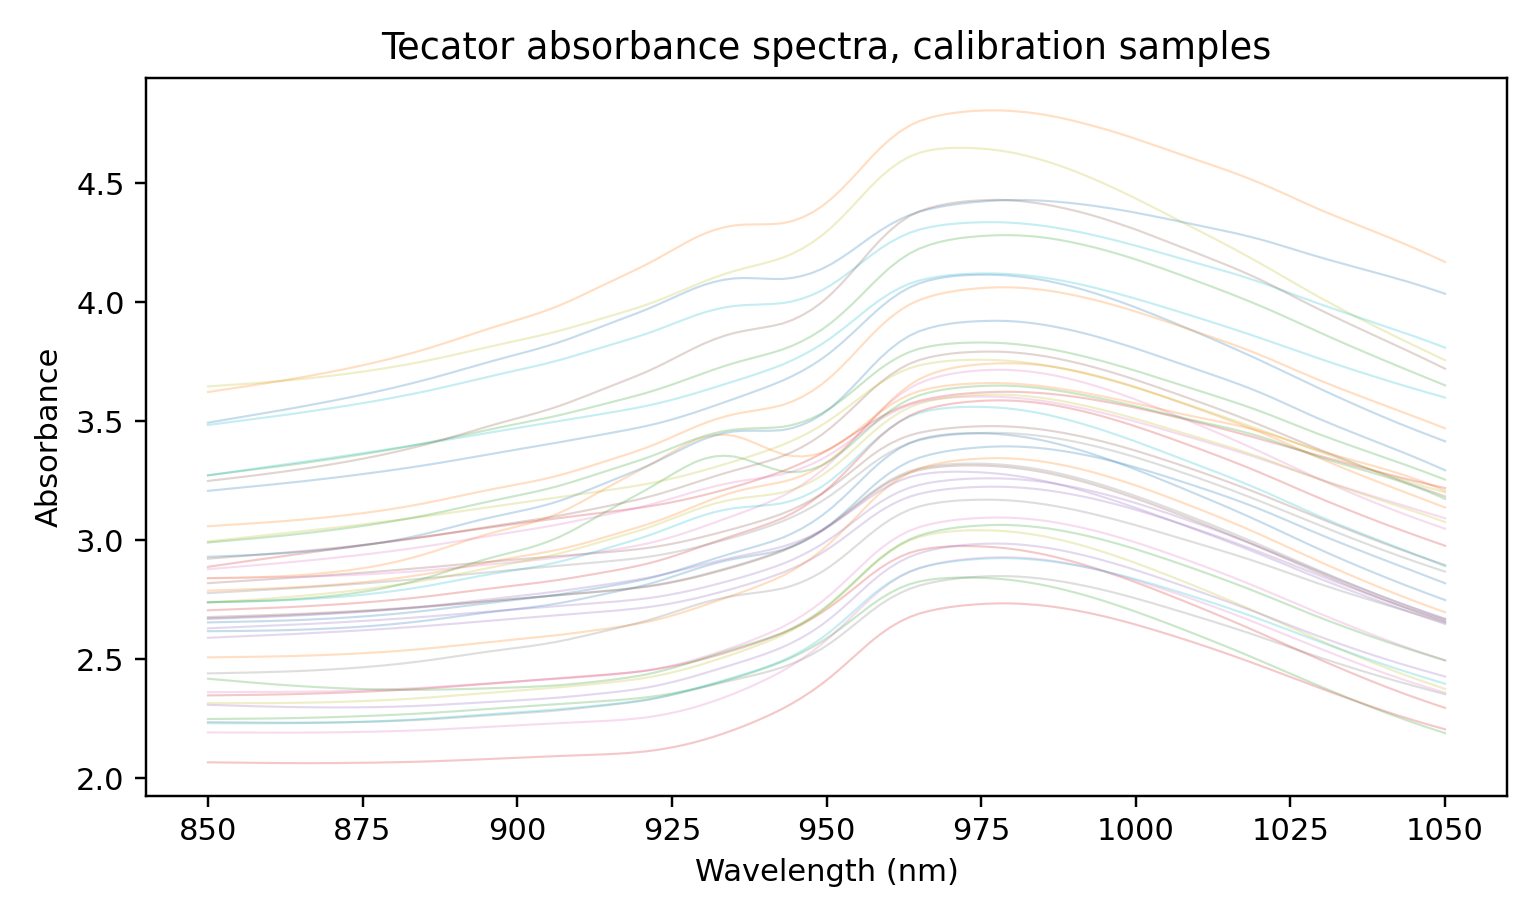

### Figure 2. Mean absorbance spectra by fat-content quartile.

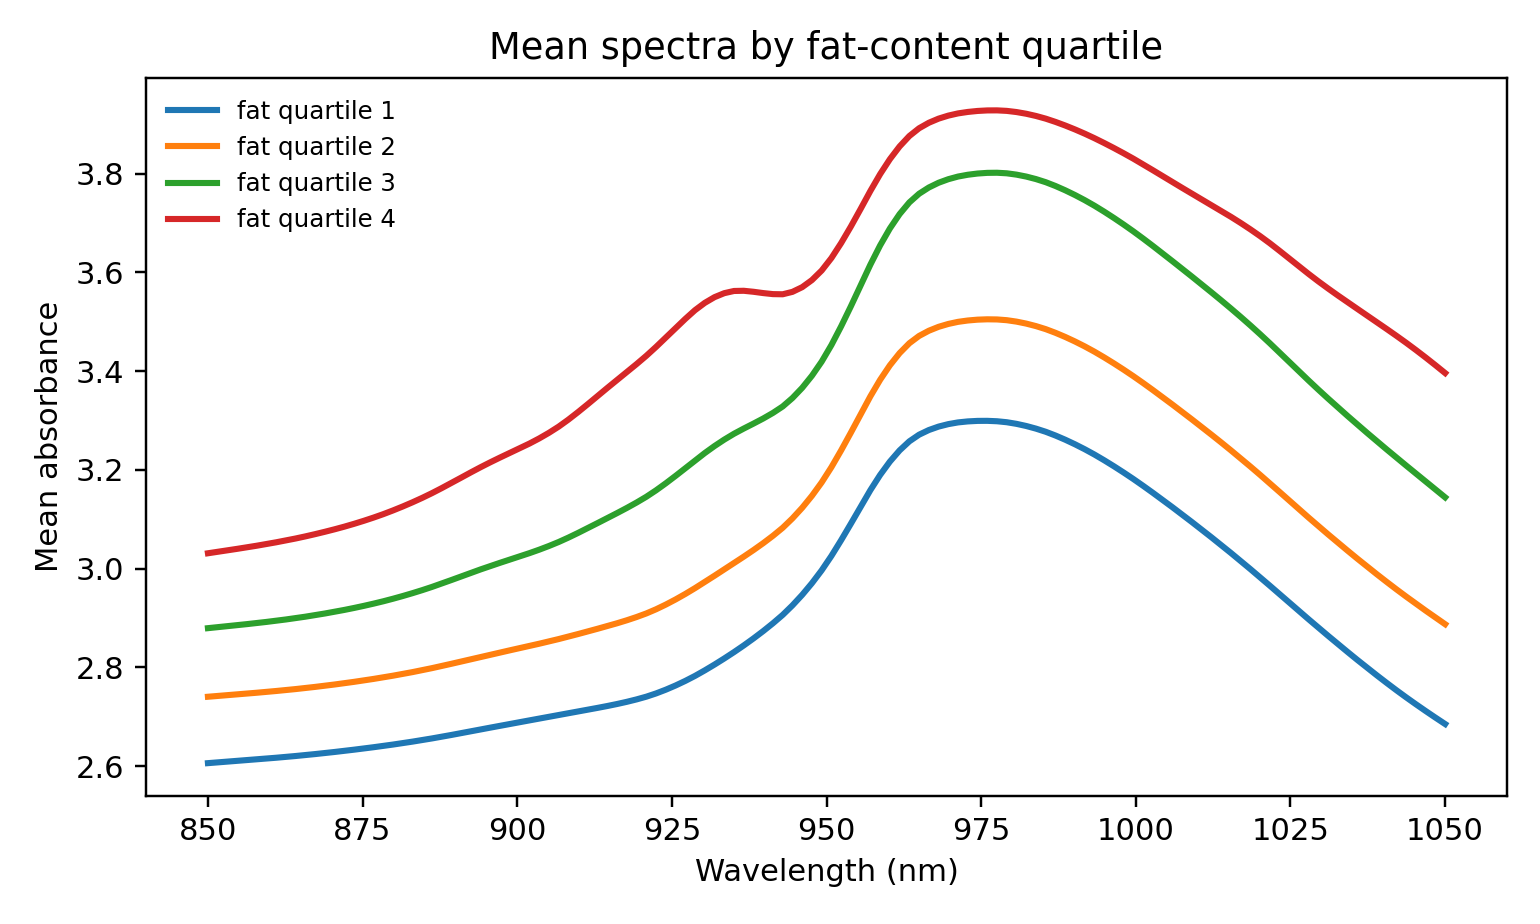

### Figure 3. Calibration-only wavelet scale weights used in the WMaxTwin geometry.

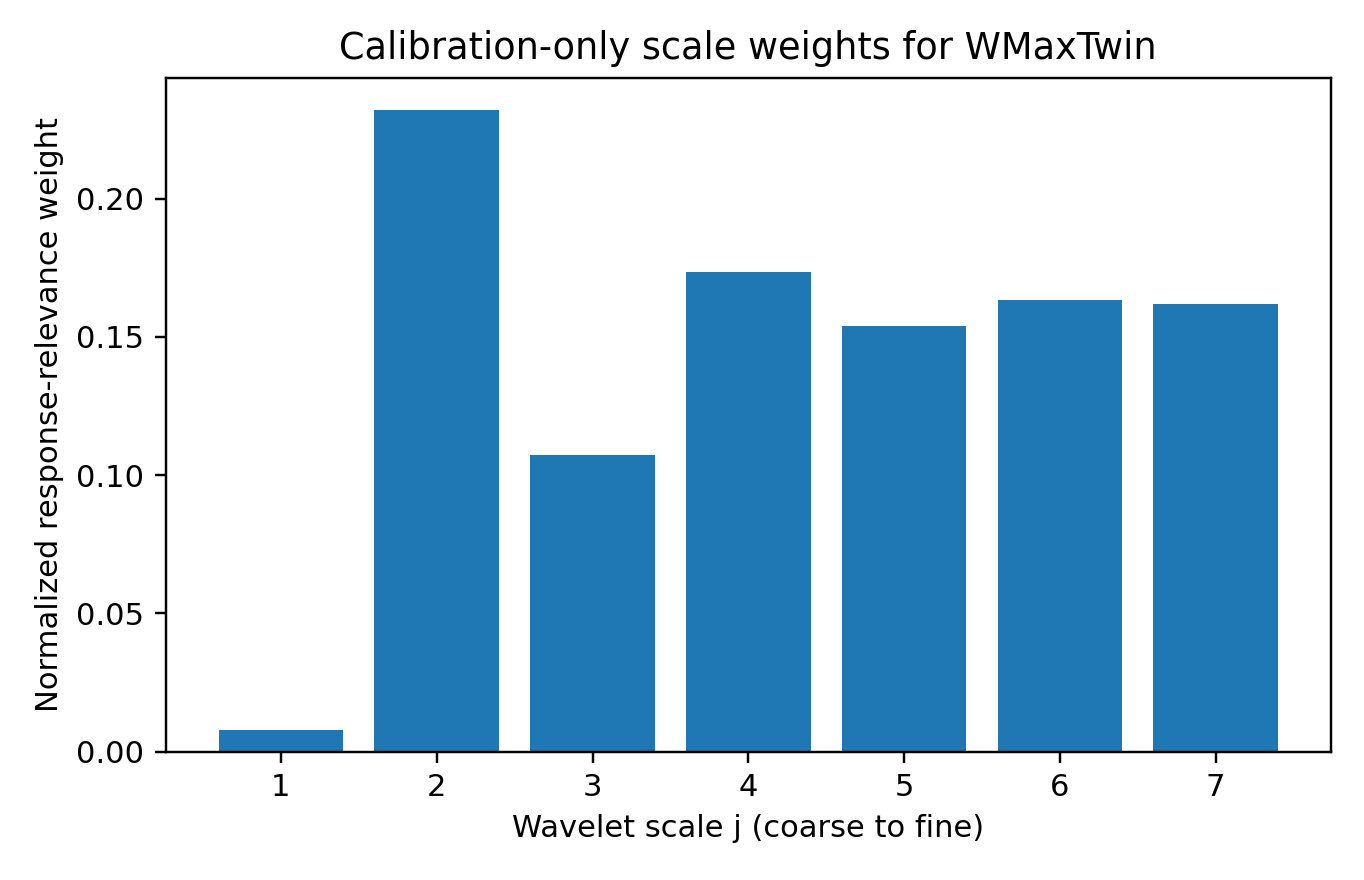

### Figure 4. Example validation curves for the first repetition.

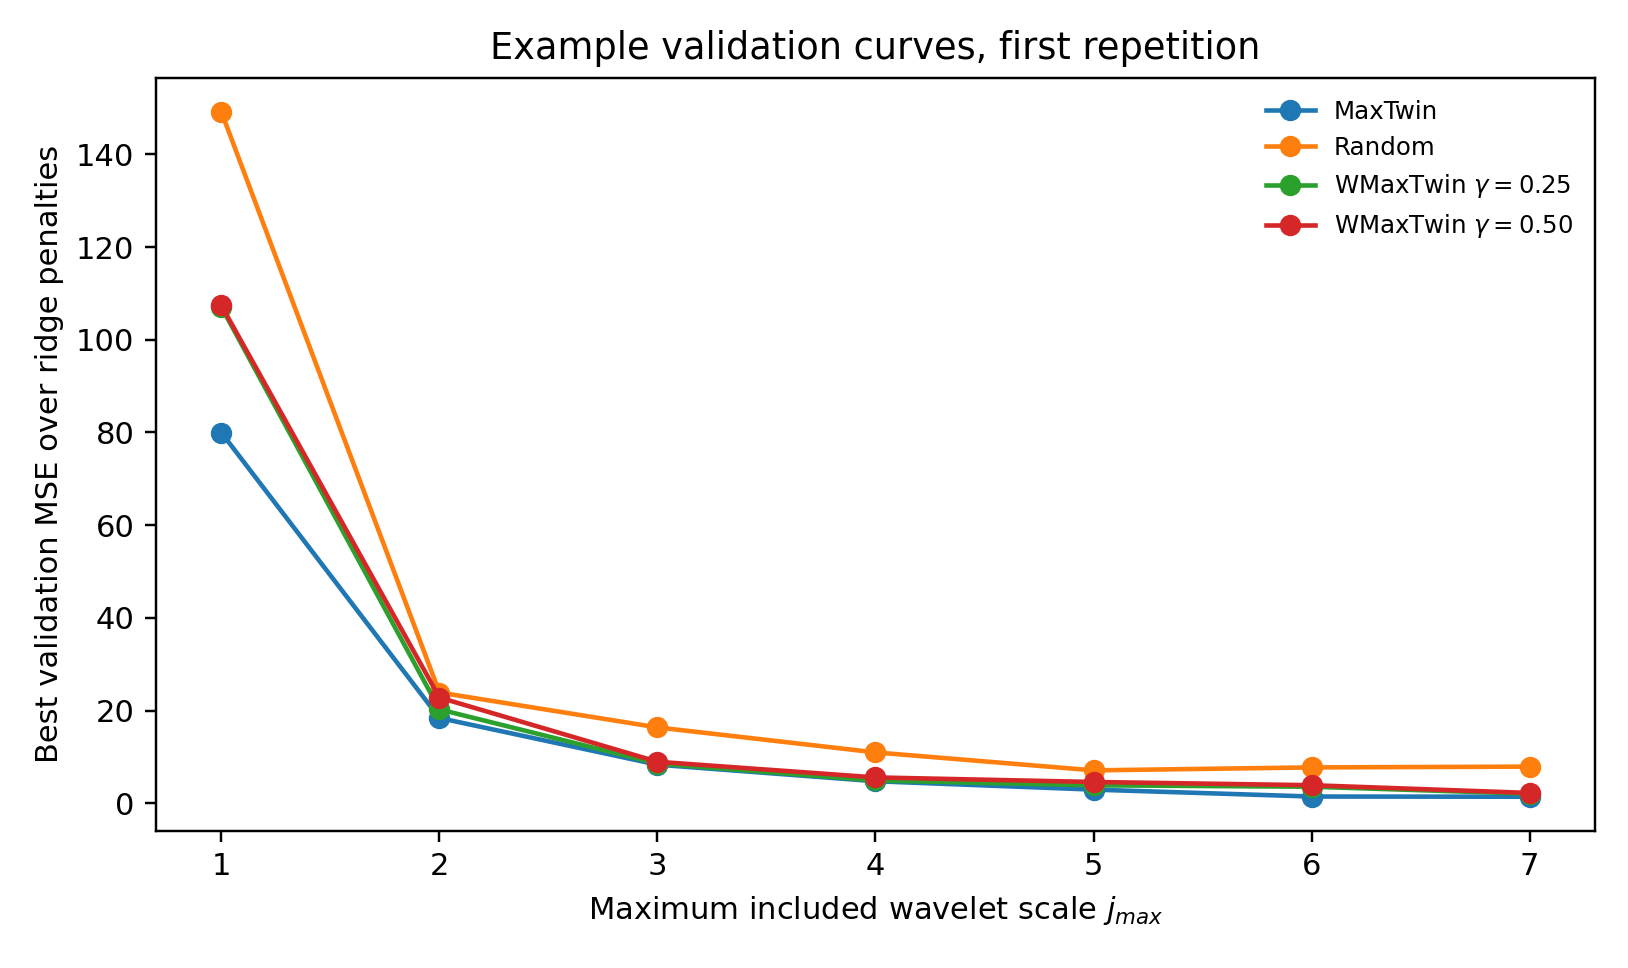

### Figure 5. External test RMSE across repeated internal train-validation splits.

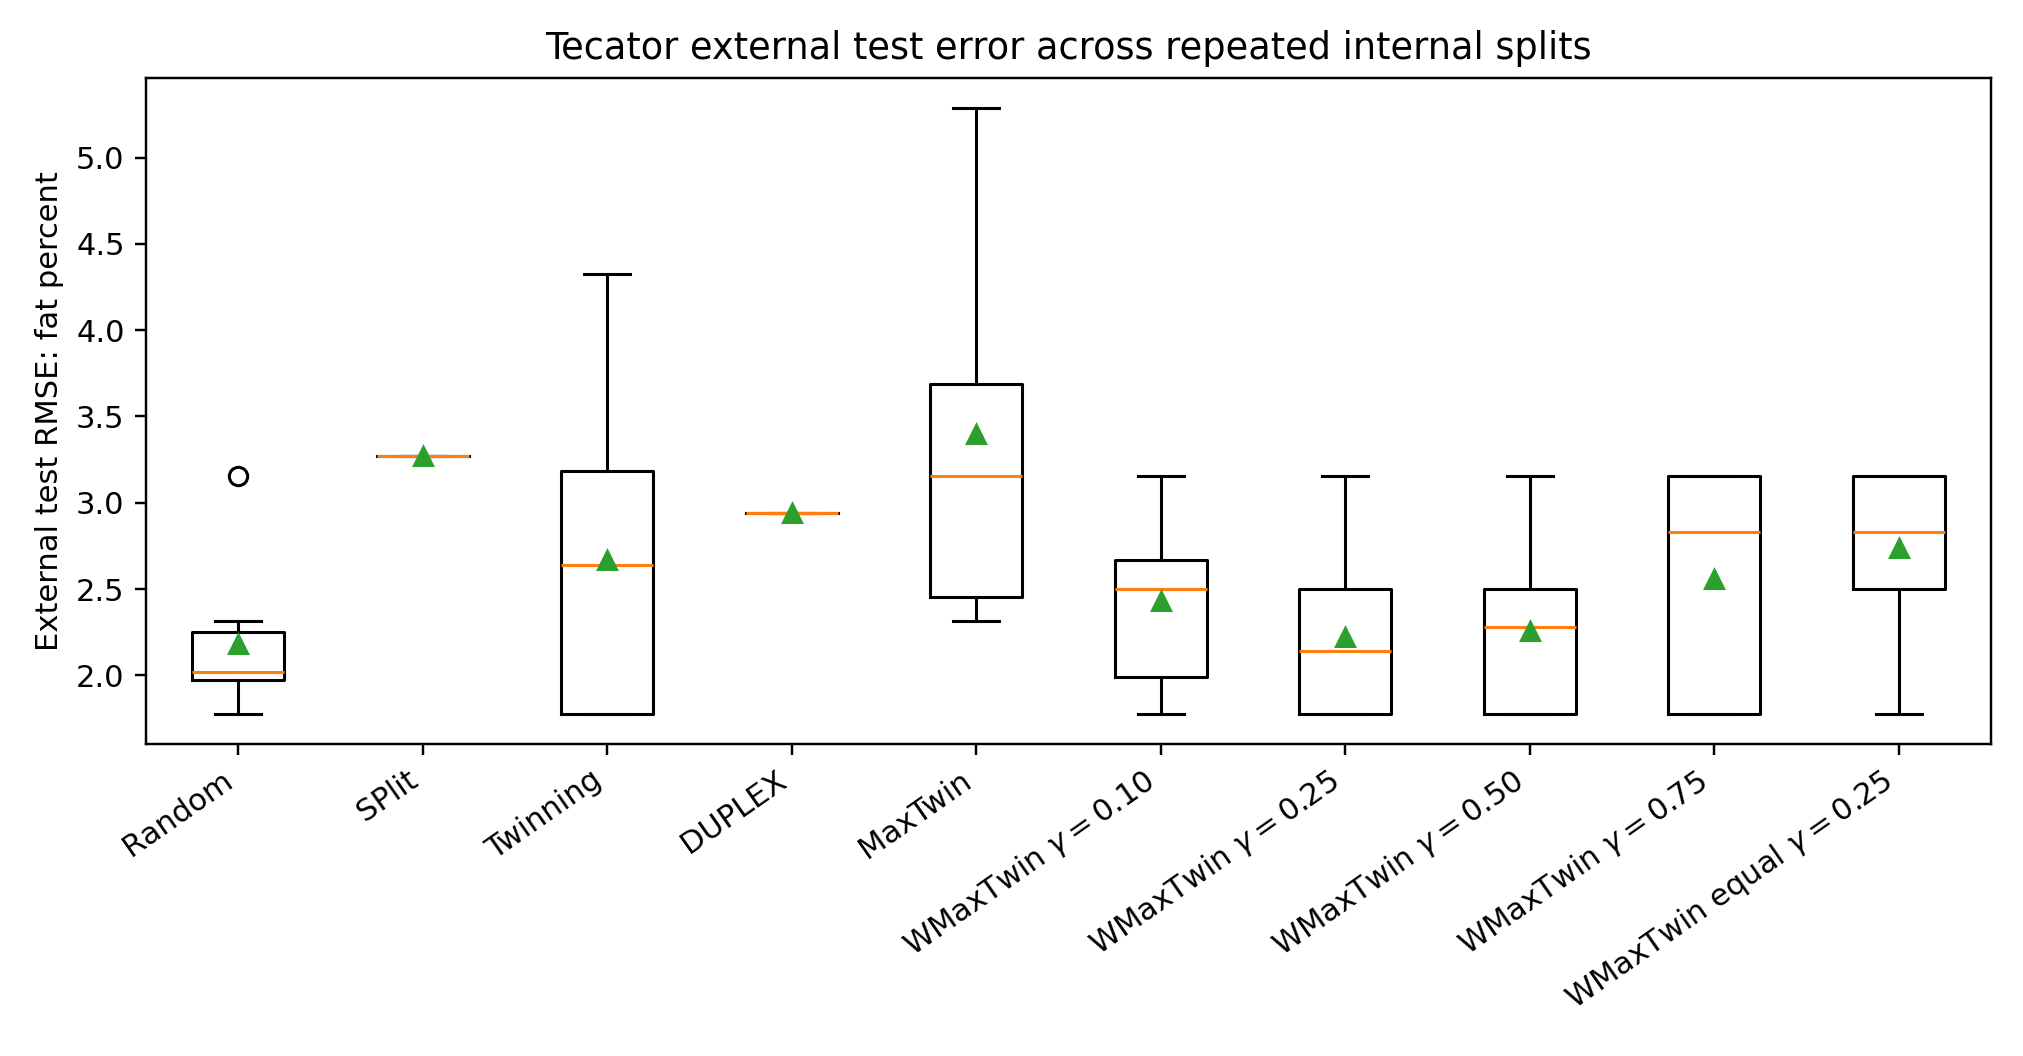

### Figure 6. Selected wavelet-resolution cutoff across repeated internal splits.

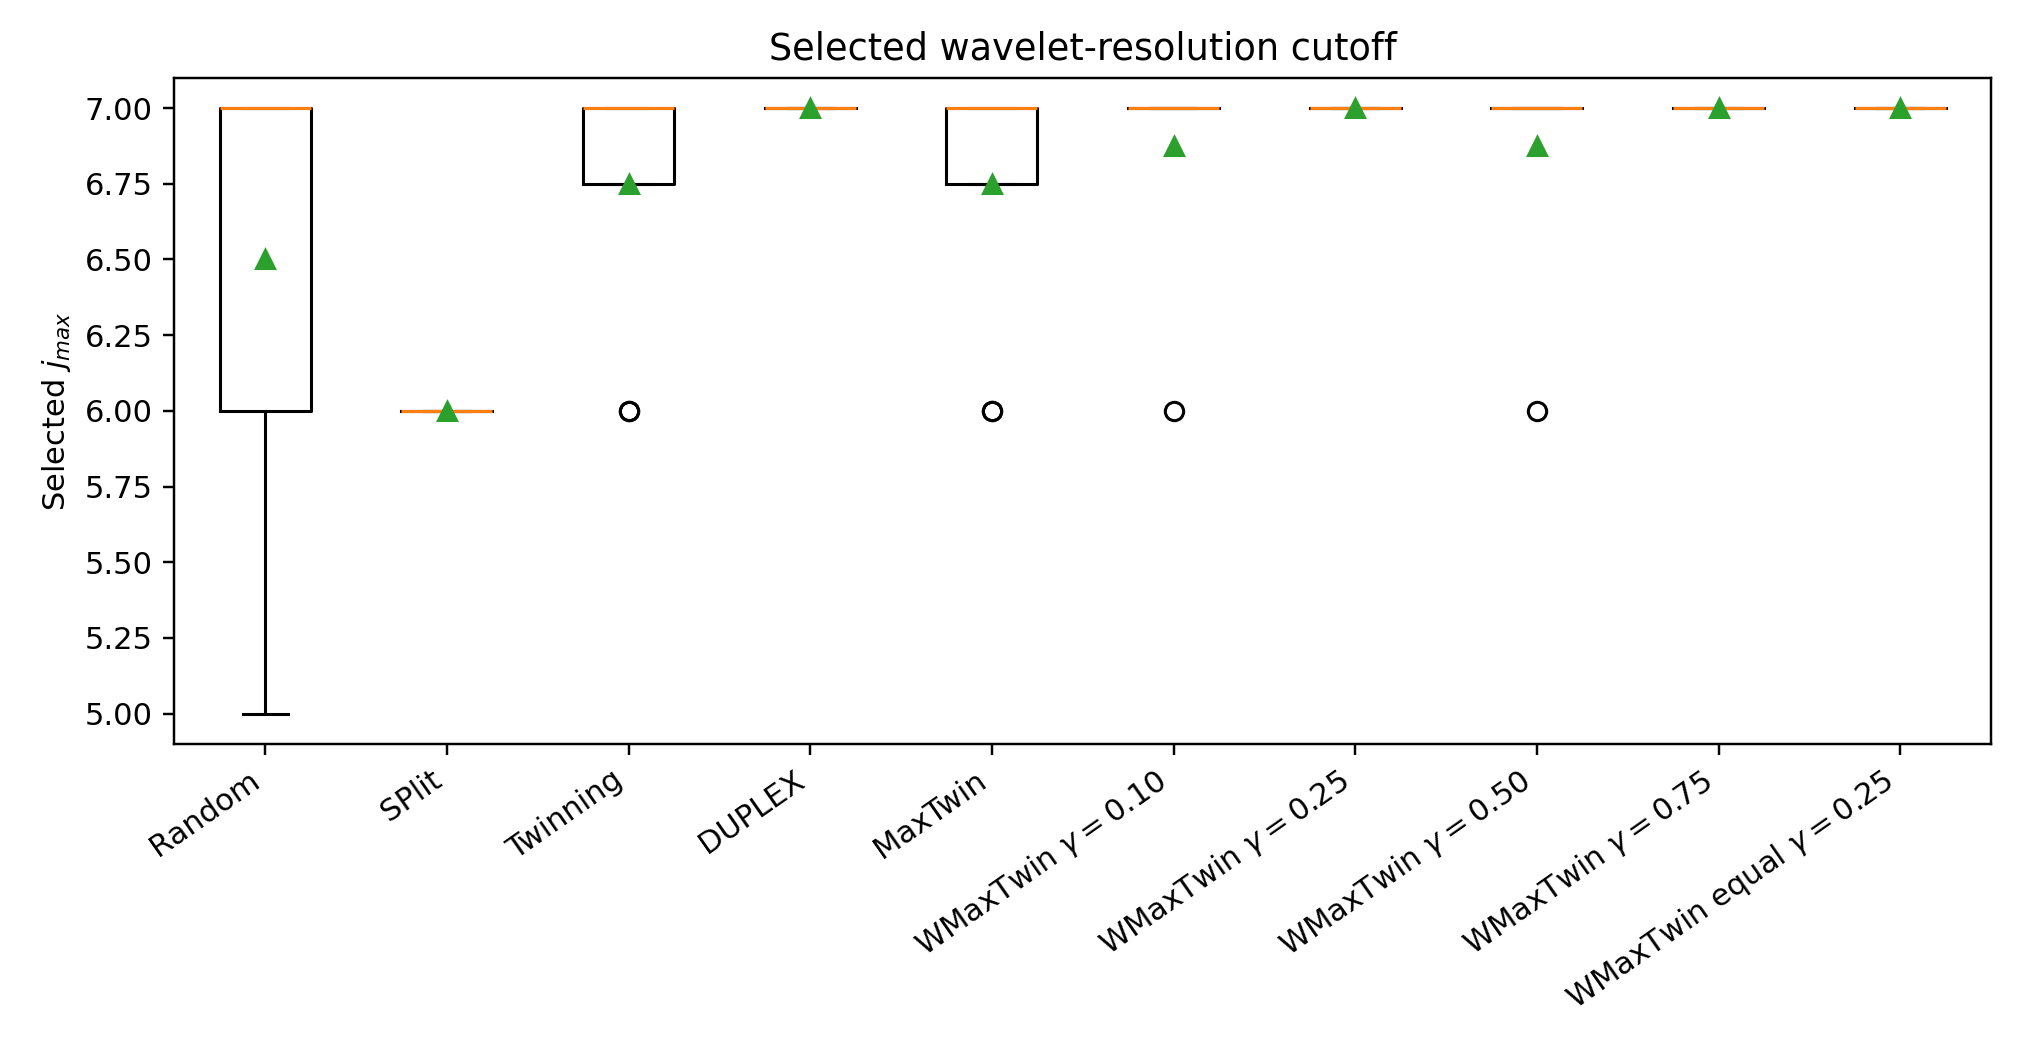

### Figure 7. Selected ridge penalty across repeated internal splits.

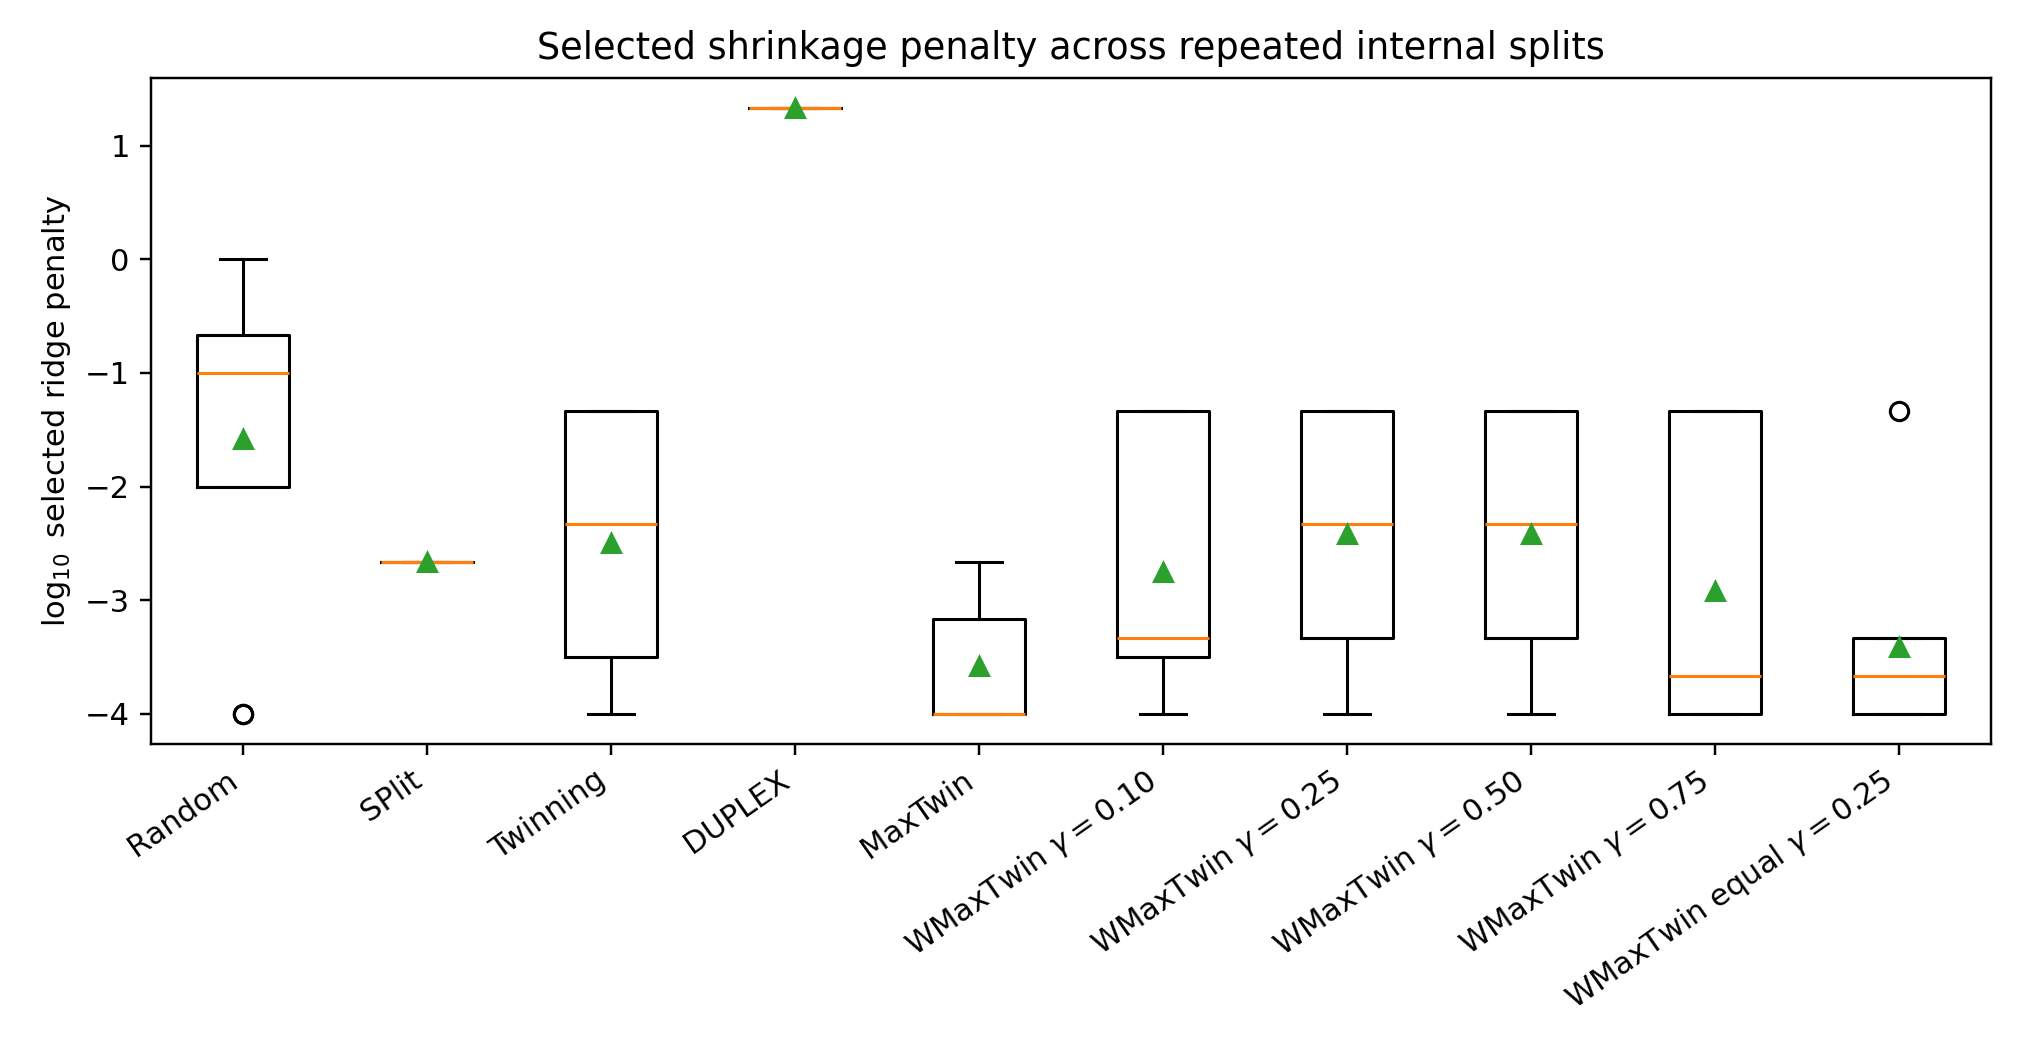

### Figure 8. Nested WMaxTwin path. MaxTwin is gamma=0; positive gamma adds scale-weighted wavelet geometry.

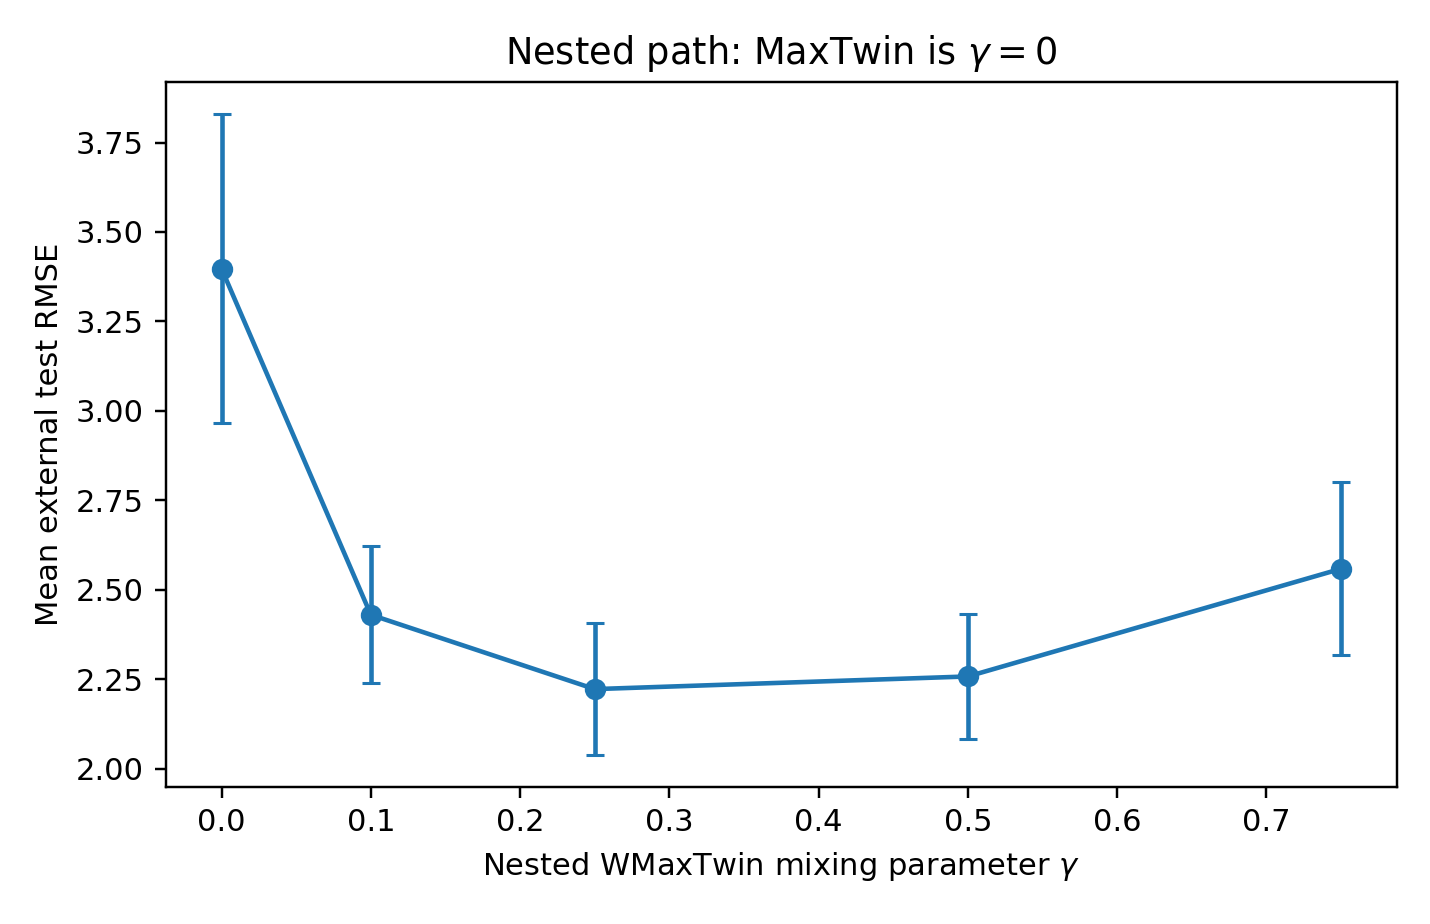

In [12]:
from IPython.display import Image, display, Markdown

figs = [
    ("fig1_tecator_spectra.png", "Figure 1. Tecator absorbance spectra for calibration samples."),
    ("fig2_quartile_mean_spectra.png", "Figure 2. Mean absorbance spectra by fat-content quartile."),
    ("fig3_response_scale_weights.png", "Figure 3. Calibration-only wavelet scale weights used in the WMaxTwin geometry."),
    ("fig4_validation_curves_rep0.png", "Figure 4. Example validation curves for the first repetition."),
    ("fig5_test_rmse_boxplot.png", "Figure 5. External test RMSE across repeated internal train-validation splits."),
    ("fig6_selected_jmax_boxplot.png", "Figure 6. Selected wavelet-resolution cutoff across repeated internal splits."),
    ("fig7_selected_alpha_boxplot.png", "Figure 7. Selected ridge penalty across repeated internal splits."),
    ("fig8_gamma_path_rmse.png", "Figure 8. Nested WMaxTwin path. MaxTwin is gamma=0; positive gamma adds scale-weighted wavelet geometry."),
]

for fname, caption in figs:
    path = OUTDIR / fname
    display(Markdown(f"### {caption}"))
    display(Image(filename=str(path)))

## Interpretation

The endpoint $\gamma=0$ is ordinary MaxTwin in the raw standardized functional geometry.  Positive values of $\gamma$ add scale-weighted wavelet geometry.  In this run, raw MaxTwin has the smallest mean validation MSE but poor external RMSE, which indicates an internally easy validation problem that does not transfer well.  Moderate WMaxTwin perturbations, especially $\gamma=0.25$ and $\gamma=0.50$, improve and stabilize external prediction.

The equal-weight WMaxTwin diagnostic is important.  It performs worse than response-weighted WMaxTwin, which supports the idea that the weights should reflect scientifically or predictively relevant scales, not simply raw wavelet energy or equal scale emphasis.

The conclusion is cautious: WMaxTwin does not automatically dominate all split geometries.  The useful diagnostic is the nested path.  Here the path shows that moderate scale-aware perturbations of ordinary MaxTwin can reduce external test error in a functional-regression problem where the signal is genuinely multiresolution.

## Reproducibility notes

The notebook writes all generated outputs to `tecator_wmaxtwin_outputs/`:

- `tecator_split_results.csv`: all repeated split-level results.
- `tecator_split_summary.csv`: table summary.
- `tecator_scale_weights.csv`: scale weights.
- `fig1_...png` through `fig8_...png`: generated figures.
- `tecator_wmaxtwin_section.tex`: LaTeX section generated by the standalone script.

The local file `tecator_statlib.txt` is included to make the notebook independent of network access.  If the file is removed, the loader attempts to download the StatLib file from the public URL defined in the code.